# Assignment 2 

Visualization Pipeline

**Story:** "Time Traveler Timmy visits San Francisco"

Three visualizations:
1. **Static chart** — Weekly street-crime pattern (safest calendar week)
2. **Map** — District safety during the safest week (choropleth)
3. **Interactive Plotly** — Hourly crime pattern in the safest district during that week

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import json
import os

# ── Load and filter data ─────────────────────────────────────────────────────
merged_df = pd.read_csv("../../data/sf_crime_merged.csv")
merged_df["Incident Date"] = pd.to_datetime(merged_df["Incident Date"])

STREET_CRIME_CATEGORIES = ["Assault", "Robbery", "Rape", "Sex Offense"]

street_df = merged_df[
    merged_df["Unified Category"].isin(STREET_CRIME_CATEGORIES)
].copy()

# Exclude 2018 (dataset merge seam) and 2020 (COVID anomaly), cap at 2025
street_df = street_df[~street_df["Incident Date"].dt.year.isin([2018, 2020])]
street_df = street_df[street_df["Incident Date"].dt.year <= 2025]

# Add temporal columns
street_df["year"] = street_df["Incident Date"].dt.year
street_df["week"] = street_df["Incident Date"].dt.isocalendar().week.astype(int)
street_df["hour"] = street_df["Incident Time"].str[:2].astype(int)

# Drop partial week 53
street_df = street_df[street_df["week"] <= 52]

# Export to docs/assets (GitHub Pages serves from /docs)
EXPORT_DIR = "../../docs/assets"
os.makedirs(EXPORT_DIR, exist_ok=True)

n_years = street_df["year"].nunique()
print(f"Street crime incidents: {len(street_df):,}")
print(f"Years included ({n_years}): {sorted(street_df['year'].unique())}")
print(f"Crime categories: {STREET_CRIME_CATEGORIES}")

Street crime incidents: 240,670
Years included (21): [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2019), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Crime categories: ['Assault', 'Robbery', 'Rape', 'Sex Offense']


## Visualization 1:
Weekly Street Crime Pattern (Static)

Average street-crime incidents per calendar week, across all included years.
This reveals seasonal patterns — Timmy uses it to pick the safest week to travel.

Safest week: 52 (avg 190.7 incidents/year)


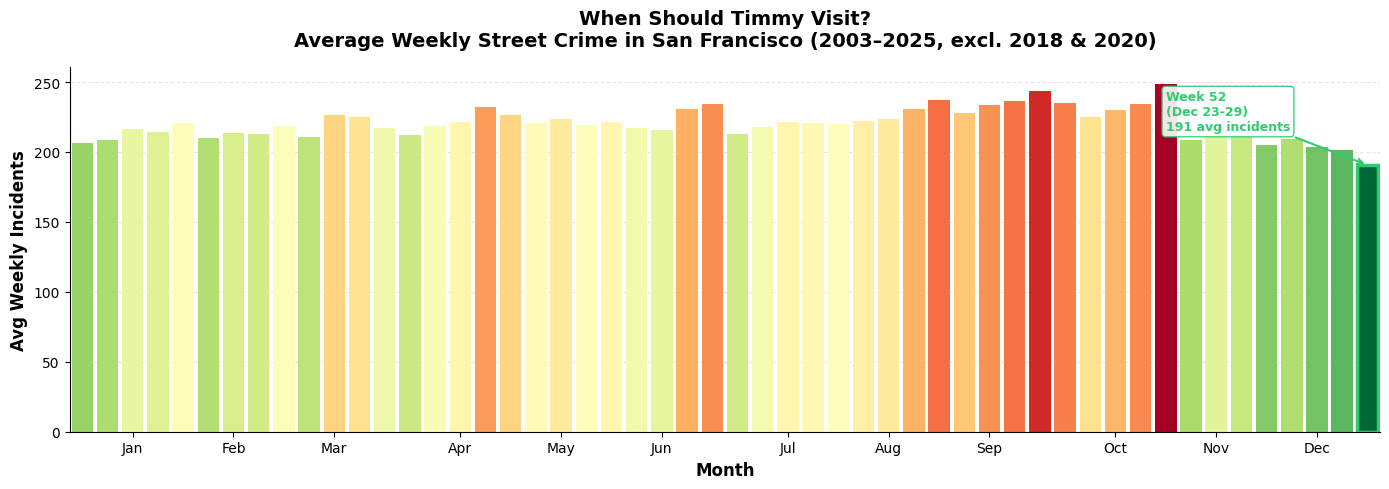

Exported to ../../docs/assets/viz1_weekly_pattern.svg


In [2]:
import datetime

# ── Viz 1: Weekly pattern ─────────────────────────────────────────────────────
weekly_avg = (street_df.groupby("week").size() / n_years).reset_index(
    name="avg_incidents"
)
weekly_avg.columns = ["week", "avg_incidents"]

safest_week = int(weekly_avg.loc[weekly_avg["avg_incidents"].idxmin(), "week"])  # type: ignore
safest_avg = weekly_avg.loc[weekly_avg["avg_incidents"].idxmin(), "avg_incidents"]
print(f"Safest week: {safest_week} (avg {safest_avg:.1f} incidents/year)")

# ── Approximate month labels for x-axis ──────────────────────────────────────

month_ticks = []
month_labels = []
for m in range(1, 13):
    d = datetime.date(2024, m, 15)
    iso_week = d.isocalendar()[1]
    month_ticks.append(iso_week)
    month_labels.append(d.strftime("%b"))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Color palette: green for safe, red for dangerous
colors = plt.cm.RdYlGn_r(  # type: ignore
    (weekly_avg["avg_incidents"] - weekly_avg["avg_incidents"].min())
    / (weekly_avg["avg_incidents"].max() - weekly_avg["avg_incidents"].min())
)

bars = ax.bar(
    weekly_avg["week"],
    weekly_avg["avg_incidents"],
    color=colors,
    width=0.85,
    edgecolor="none",
)

# Highlight the safest week
safest_idx = weekly_avg[weekly_avg["week"] == safest_week].index[0]
bars[safest_idx].set_edgecolor("#2ecc71")
bars[safest_idx].set_linewidth(2.5)

# Annotate safest week
ax.annotate(
    f"Week {safest_week}\n(Dec 23-29)\n{safest_avg:.0f} avg incidents",
    xy=(safest_week, safest_avg),  # type: ignore
    xytext=(safest_week - 8, safest_avg + 25),  # type: ignore
    fontsize=9,
    fontweight="bold",
    color="#2ecc71",
    arrowprops=dict(arrowstyle="->", color="#2ecc71", lw=1.5),
    bbox=dict(
        boxstyle="round,pad=0.3", facecolor="white", edgecolor="#2ecc71", alpha=0.9
    ),
)

# Styling
ax.set_xlabel("Month", fontsize=12, fontweight="bold")
ax.set_ylabel("Avg Weekly Incidents", fontsize=12, fontweight="bold")
ax.set_title(
    "When Should Timmy Visit?\nAverage Weekly Street Crime in San Francisco (2003–2025, excl. 2018 & 2020)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, fontsize=10)
ax.set_xlim(0.5, 52.5)

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=10)

# Add subtle grid
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{EXPORT_DIR}/viz1_weekly_pattern.svg", bbox_inches="tight", dpi=150)
plt.savefig(f"{EXPORT_DIR}/viz1_weekly_pattern.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Exported to {EXPORT_DIR}/viz1_weekly_pattern.svg")

## Visualization 2: District Safety Map (Choropleth)

Average street-crime incidents per district during the safest week (week 52 — Christmas week),
across all included years. Timmy uses this to pick the safest district for his hotel.

In [3]:
import urllib.request

# ── Viz 2: District danger score choropleth ────────────────────────────────────

# Expand crime set + merge sexual violence labels (same as Act I)
df_map = street_df.copy()
df_map["Unified Category"] = df_map["Unified Category"].replace(
    {"Rape": "Sexual Violence", "Sex Offense": "Sexual Violence"}
)
CRIMES_EXP = ["Assault", "Robbery", "Sexual Violence", "Arson"]
SEV = {"Assault": 1.0, "Robbery": 1.5, "Sexual Violence": 3.0, "Arson": 0.8}

# Filter to safest week, exclude out-of-city reports
week_df = df_map[
    (df_map["week"] == safest_week) & (df_map["Police District"] != "Out Of Sf")
]

# Pivot: avg incidents per crime type per district
dist_pivot = (
    week_df.groupby(["Police District", "Unified Category"]).size()
    .unstack(fill_value=0) / n_years
)
for c in CRIMES_EXP:
    if c not in dist_pivot.columns:
        dist_pivot[c] = 0.0

# Severity-weighted composite, then 0-100 danger score
dist_pivot["weighted"] = sum(dist_pivot[c] * SEV[c] for c in CRIMES_EXP)
w_min, w_max = dist_pivot["weighted"].min(), dist_pivot["weighted"].max()
dist_pivot["danger_score"] = (dist_pivot["weighted"] - w_min) / (w_max - w_min) * 100

district_avg = dist_pivot.reset_index()
district_avg.columns.name = None
district_avg["district_upper"] = district_avg["Police District"].str.upper()

safest_district = district_avg.loc[district_avg["danger_score"].idxmin(), "Police District"]
print(f"Safest district during week {safest_week}: {safest_district}")
print(f"\nDistrict danger scores (week {safest_week}):")
print(
    district_avg.sort_values("danger_score")[
        ["Police District", "danger_score", "weighted", "Assault", "Robbery", "Sexual Violence", "Arson"]
    ].round(1).to_string(index=False)
)

# ── Load GeoJSON ──────────────────────────────────────────────────────────────
GEOJSON_URL = "https://raw.githubusercontent.com/suneman/socialdata2025/main/files/sfpd.geojson"
with urllib.request.urlopen(GEOJSON_URL) as response:
    geojson = json.load(response)

# ── Choropleth ────────────────────────────────────────────────────────────────
fig = px.choropleth_map(
    data_frame=district_avg,
    geojson=geojson,
    locations="district_upper",
    featureidkey="properties.DISTRICT",
    color="danger_score",
    color_continuous_scale=[
        [0.0,  "#2ecc71"],   # 0  = safest  = green
        [0.5,  "#f39c12"],   # 50 = mid     = amber
        [1.0,  "#e74c3c"],   # 100= danger  = red
    ],
    range_color=[0, 100],
    map_style="carto-positron",
    zoom=11,
    center={"lat": 37.757, "lon": -122.449},
    opacity=0.75,
    labels={"danger_score": "Danger Score (0–100)", "district_upper": "District"},
    title=f"Where Should Timmy Stay?<br><sub>District Danger Score During Christmas Week (Week {safest_week})</sub>",
    hover_data={
        "Police District": True,
        "danger_score": ":.0f",
        "weighted": ":.1f",
        "district_upper": False,
    },
)

fig.update_layout(
    margin=dict(l=0, r=0, t=60, b=0),
    coloraxis_colorbar=dict(
        title="Danger Score<br>(0 = safest)",
        thickness=15,
        len=0.6,
        tickvals=[0, 25, 50, 75, 100],
    ),
)

fig.show()
fig.write_html(f"{EXPORT_DIR}/viz2_district_map.html", include_plotlyjs="cdn")
print(f"Exported to {EXPORT_DIR}/viz2_district_map.html")


Safest district during week 52: Richmond

District danger scores (week 52):
Police District  danger_score  weighted  Assault  Robbery  Sexual Violence  Arson
       Richmond           0.0       8.5      5.4      1.6              0.2    0.0
           Park           1.7       9.0      5.3      2.2              0.1    0.0
        Taraval          10.7      11.5      8.0      2.0              0.1    0.0
      Ingleside          56.8      24.4     12.6      6.1              0.9    0.0
        Central          58.3      24.8     14.7      5.5              0.6    0.0
        Bayview          60.7      25.5     15.8      5.8              0.3    0.0
       Northern          63.3      26.2     15.5      5.7              0.7    0.0
     Tenderloin          64.0      26.4     16.3      5.7              0.5    0.0
        Mission          89.8      33.5     20.2      7.5              0.7    0.0
       Southern         100.0      36.4     21.5      7.4              1.3    0.0


Exported to ../../docs/assets/viz2_district_map.html


## Visualization 3: Hourly Crime Pattern — Interactive (Plotly)

Hourly distribution of street crime in the Richmond district during Christmas week,
averaged across all included years. Timmy uses this to plan his daily schedule.

In [4]:
# ── Viz 3: Hourly crime pattern (interactive) ────────────────────────────────

# Filter: safest district + safest week, across all years
hourly_df = street_df[
    (street_df["week"] == safest_week)
    & (street_df["Police District"] == safest_district)
].copy()

print(f"District: {safest_district}, Week: {safest_week}")
print(f"Total incidents across {n_years} years: {len(hourly_df)}")

# Aggregate by hour and crime type, average across years
hourly_by_type = (
    hourly_df.groupby(["hour", "Unified Category"])
    .size()
    .reset_index(name="total_count")
)
hourly_by_type["avg_count"] = hourly_by_type["total_count"] / n_years
hourly_by_type = hourly_by_type.rename(columns={"Unified Category": "Crime Type"})

# ── Color palette ────────────────────────────────────────────────────────────
crime_colors = {
    "Assault": "#e74c3c",
    "Robbery": "#f39c12",
    "Rape": "#8e44ad",
    "Sex Offense": "#2c3e50",
}

# ── Build interactive figure ─────────────────────────────────────────────────
fig = go.Figure()

for crime_type in STREET_CRIME_CATEGORIES:
    ct_data = hourly_by_type[hourly_by_type["Crime Type"] == crime_type]
    full_hours = pd.DataFrame({"hour": range(24)})
    ct_data = full_hours.merge(ct_data, on="hour", how="left").fillna(0)

    fig.add_trace(
        go.Bar(
            x=ct_data["hour"],
            y=ct_data["avg_count"],
            name=crime_type,
            marker_color=crime_colors[crime_type],
            opacity=0.85,
            hovertemplate=(
                f"<b>{crime_type}</b><br>"
                "Hour: %{x}:00<br>"
                "Avg incidents/year: %{y:.2f}"
                "<extra></extra>"
            ),
        )
    )

fig.update_layout(
    title=dict(
        text=(
            f"Hourly Street Crime in {safest_district} During Christmas Week"
            f"<br><sub>Averaged over {n_years} years (2003-2025, excl. 2018 & 2020)</sub>"
        ),
        font=dict(size=14),
    ),
    xaxis=dict(
        title="Hour of Day",
        tickmode="array",
        tickvals=list(range(0, 24, 2)),
        ticktext=[f"{h}:00" for h in range(0, 24, 2)],
        range=[-0.5, 23.5],
    ),
    yaxis=dict(
        title="Avg Incidents per Year",
        rangemode="tozero",
    ),
    barmode="stack",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.15,
        xanchor="center",
        x=0.5,
        title=None,
    ),
    hoverlabel=dict(bgcolor="white", font_size=12),
    template="plotly_white",
    margin=dict(l=50, r=20, t=80, b=80),
    height=420,
)

fig.show()
fig.write_html(f"{EXPORT_DIR}/viz3_hourly_interactive.html", include_plotlyjs="cdn")
print(f"Exported to {EXPORT_DIR}/viz3_hourly_interactive.html")

District: Richmond, Week: 52
Total incidents across 21 years: 152


Exported to ../../docs/assets/viz3_hourly_interactive.html


## Alternative Viz 1 Options

Two alternatives to the plain bar chart for the weekly pattern. Compare and pick.

Safest week: 52  (226.7 weighted index)
Peak week:   44  (299.0 weighted index)
Ratio peak/safest: 1.32x


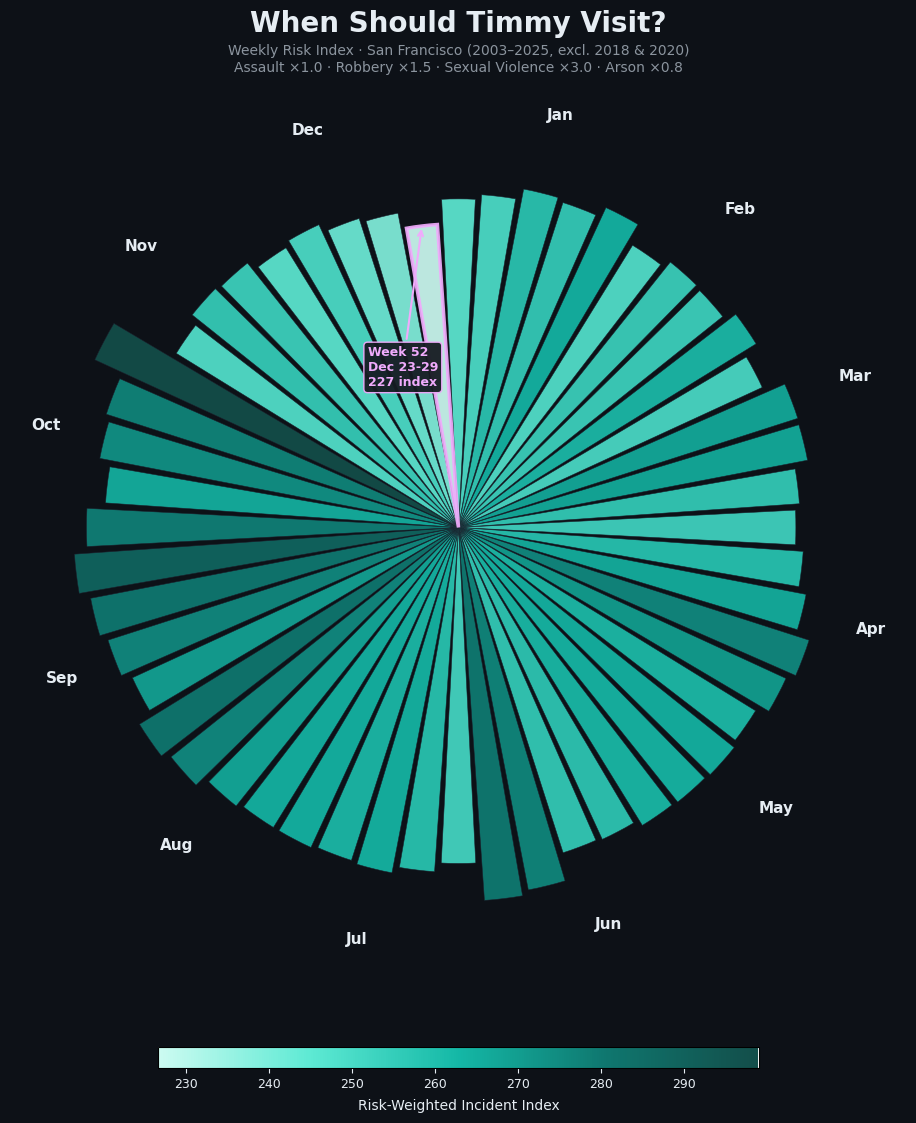

Exported viz1_alt_radial.svg / .png


In [5]:

# ── Viz 1: Radial bar chart — severity-weighted, no normalisation ─────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
import datetime as dt

# Merge Rape + Sex Offense → Sexual Violence (same crime, different era labels)
df_radial = street_df.copy()
df_radial["Unified Category"] = df_radial["Unified Category"].replace(
    {"Rape": "Sexual Violence", "Sex Offense": "Sexual Violence"}
)
CRIMES_EXP = ["Assault", "Robbery", "Sexual Violence", "Arson"]
SEV = {"Assault": 1.0, "Robbery": 1.5, "Sexual Violence": 3.0, "Arson": 0.8}

exp_df = df_radial[df_radial["Unified Category"].isin(CRIMES_EXP)].copy()

weekly_pivot = (
    exp_df.groupby(["week", "Unified Category"]).size()
    .unstack(fill_value=0) / n_years
)
for c in CRIMES_EXP:
    if c not in weekly_pivot.columns:
        weekly_pivot[c] = 0.0

# Severity-weighted composite — no normalisation, honest scale
values = sum(weekly_pivot[c] * SEV[c] for c in CRIMES_EXP)

safest_week = int(values.idxmin())
safest_val  = values[safest_week]
peak_val    = values.max()
print(f"Safest week: {safest_week}  ({safest_val:.1f} weighted index)")
print(f"Peak week:   {int(values.idxmax())}  ({peak_val:.1f} weighted index)")
print(f"Ratio peak/safest: {peak_val/safest_val:.2f}x")

# ── Geometry ─────────────────────────────────────────────────────────────────
n_weeks = len(values)
angles         = np.linspace(0, 2 * np.pi, n_weeks, endpoint=False)
angles_shifted = np.pi / 2 - angles
bar_width      = 2 * np.pi / n_weeks * 0.85

safety_cmap = mcolors.LinearSegmentedColormap.from_list(
    "teal_mono", ["#ccfbf1", "#5eead4", "#14b8a6", "#0f766e", "#134e4a"],
)
vmin, vmax = values.min(), values.max()
norm   = mcolors.Normalize(vmin=vmin, vmax=vmax)
colors = safety_cmap(norm(values.values))

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 11.5), facecolor="#0d1117")
ax  = fig.add_axes([0.05, 0.12, 0.9, 0.78], projection="polar", facecolor="#0d1117")

bars = ax.bar(
    angles_shifted, values.values,
    width=bar_width, color=colors,
    edgecolor="#1a1f2b", linewidth=0.4, alpha=0.92,
)

safest_idx = values.index.get_loc(safest_week)
bars[safest_idx].set_edgecolor("#f0abfc")
bars[safest_idx].set_linewidth(2.5)

# Month labels
label_radius = vmax * 1.06
for m in range(1, 13):
    mid_day = dt.date(2024, m, 15)
    wk_num  = mid_day.isocalendar()[1]
    if wk_num in values.index:
        idx   = values.index.get_loc(wk_num)
        angle = angles_shifted[idx]
        ax.text(angle, label_radius, mid_day.strftime("%b"),
                ha="center", va="center", fontsize=11,
                fontweight="bold", color="#e6edf3")

# Annotate safest week
safest_angle = angles_shifted[safest_idx]
ax.annotate(
    f"Week {safest_week}\nDec 23-29\n{safest_val:.0f} index",
    xy=(safest_angle, safest_val),
    xytext=(safest_angle + 0.45, vmax * 0.42),
    fontsize=9, fontweight="bold", color="#f0abfc",
    arrowprops=dict(arrowstyle="->", color="#f0abfc", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#161b22",
              edgecolor="#f0abfc", alpha=0.95),
)

ax.set_ylim(0, vmax * 1.12)
ax.set_yticks([]); ax.set_xticks([])
ax.spines["polar"].set_visible(False)
ax.grid(False)

# Titles
fig.text(0.5, 0.96, "When Should Timmy Visit?",
         ha="center", va="top", fontsize=20, fontweight="bold", color="#e6edf3")
fig.text(0.5, 0.93,
         "Weekly Risk Index · San Francisco (2003–2025, excl. 2018 & 2020)\n"
         "Assault ×1.0 · Robbery ×1.5 · Sexual Violence ×3.0 · Arson ×0.8",
         ha="center", va="top", fontsize=10, color="#8b949e")

# Colorbar
cbar_ax = fig.add_axes([0.2, 0.04, 0.6, 0.018])
cb = ColorbarBase(cbar_ax, cmap=safety_cmap, norm=norm, orientation="horizontal")
cb.set_label("Risk-Weighted Incident Index", fontsize=10, color="#e6edf3", labelpad=6)
cb.ax.xaxis.set_tick_params(color="#e6edf3")
plt.setp(cb.ax.xaxis.get_ticklabels(), color="#e6edf3", fontsize=9)

plt.savefig(f"{EXPORT_DIR}/viz1_alt_radial.svg",
            bbox_inches="tight", dpi=150, facecolor="#0d1117")
plt.savefig(f"{EXPORT_DIR}/viz1_alt_radial.png",
            bbox_inches="tight", dpi=150, facecolor="#0d1117")
plt.show()
print("Exported viz1_alt_radial.svg / .png")
